# RGB Histogram Matching + Feathered Merge

Runs entirely in Jupyter with live progress output.
No boundary exclusion — all georeferenced tiles are used.

**Steps:**
1. Histogram matching — normalises brightness per flight line (fixes alternating stripe pattern)
2. Feathered merge — reprojects and blends tiles with distance-weighted feathering

Set `TEST_MODE = True` for a quick 2-minute check, then `False` for the full mosaic.

## Cell 0 — Config (edit this cell only)

In [10]:
import os

GEOREFERENCE_OUT = r'D:\Thermal_Mosaic\RGB\georeferences\main'
CORRECTED_OUT    = r'D:\Thermal_Mosaic\RGB\georeferences\main_corrected'
MERGE_OUT        = r'D:\Thermal_Mosaic\RGB\merges\main'
SUMMARY_YML      = r'D:\Thermal_Mosaic\RGB\summary_rgb.yml'


STRIP_H    = 512    # rows per strip
TEST_MODE  = False
N_WORKERS  = 1      # ← reduce from 6 to 1 (prevents 6 simultaneous 576MB allocations)
STRIP_H    = 256    # ← reduce strip height to lower peak memory
os.makedirs(CORRECTED_OUT, exist_ok=True)
os.makedirs(MERGE_OUT,     exist_ok=True)
print('Config OK')
print(f'  Georeference : {GEOREFERENCE_OUT}')
print(f'  Corrected    : {CORRECTED_OUT}')
print(f'  Merge output : {MERGE_OUT}')
print(f'  Mode         : {"TEST (30 tiles, 1 band)" if TEST_MODE else "FULL (all tiles, 3 bands)"}')

Config OK
  Georeference : D:\Thermal_Mosaic\RGB\georeferences\main
  Corrected    : D:\Thermal_Mosaic\RGB\georeferences\main_corrected
  Merge output : D:\Thermal_Mosaic\RGB\merges\main
  Mode         : FULL (all tiles, 3 bands)


## Cell 1 — Collect georeferenced files

In [11]:
import glob

all_files = sorted(set(
    glob.glob(os.path.join(GEOREFERENCE_OUT,'**','*.JPG'), recursive=True) +
    glob.glob(os.path.join(GEOREFERENCE_OUT,'**','*.tif'), recursive=True)
))

print(f'Georeferenced files found: {len(all_files)}')
print(f'First: {os.path.basename(all_files[0])}')
print(f'Last : {os.path.basename(all_files[-1])}')

Georeferenced files found: 173
First: S1007771.JPG
Last : S1008287.JPG


## Cell 2 — Step 1: Histogram Matching

Normalises per-band (R, G, B) brightness of each flight line to the global median.
Fixes the alternating bright/dark stripe caused by NE vs SW sun angle.
Writes corrected files to `georeferences/main_corrected/`.

In [12]:
import numpy as np
import rasterio
import yaml
import time

with open(SUMMARY_YML) as f:
    summary = yaml.safe_load(f)

def stem(fp):
    return os.path.splitext(os.path.basename(fp))[0]

# Build stem range per line
line_stem_ranges = {}
for name, cfg in summary['lines'].items():
    s = os.path.splitext(cfg['start_img'])[0]
    e = os.path.splitext(cfg['end_img'])[0]
    line_stem_ranges[name] = (s, e)

def get_line(fp):
    s = stem(fp)
    for name, (ls, le) in line_stem_ranges.items():
        if ls <= s <= le:
            return name
    return None

# Compute per-line mean brightness from middle frames
print('Computing per-line brightness...')
line_means = {}
for name, (ls, le) in line_stem_ranges.items():
    line_fps = [fp for fp in all_files if ls <= stem(fp) <= le]
    if not line_fps:
        continue
    # Sample middle 3 frames
    mid = len(line_fps)//2
    sample_fps = line_fps[max(0,mid-1):mid+2]
    vals = []
    for fp in sample_fps:
        with rasterio.open(fp) as src:
            data = src.read().astype(np.float32)
            mask = np.all(data > 0, axis=0)
            if mask.sum() > 100:
                vals.append(data[:, mask].mean(axis=1))
    if vals:
        line_means[name] = np.stack(vals).mean(axis=0)  # shape (3,) or (1,)
        m = line_means[name]
        print(f'  {name}: R={m[0]:.1f} G={m[1]:.1f} B={m[2]:.1f}  ({len(line_fps)} files)')

# Global reference per band
ref_mean = np.median(np.stack(list(line_means.values())), axis=0)
print(f'\nReference: R={ref_mean[0]:.1f} G={ref_mean[1]:.1f} B={ref_mean[2]:.1f}')

# Apply per-band gain correction
print('\nApplying histogram correction...')
t0 = time.time()
n_written = 0
for name, (ls, le) in line_stem_ranges.items():
    if name not in line_means:
        continue
    gain = ref_mean / np.maximum(line_means[name], 1.0)
    line_fps = [fp for fp in all_files if ls <= stem(fp) <= le]
    for fp in line_fps:
        out_fp = os.path.join(CORRECTED_OUT, os.path.basename(fp))
        if not os.path.exists(out_fp):  # skip if already done
            with rasterio.open(fp) as src:
                profile = src.profile.copy()
                data = src.read().astype(np.float32)
            corrected = np.clip(data * gain[:, None, None], 0, 255).astype(np.uint8)
            with rasterio.open(out_fp, 'w', **profile) as dst:
                dst.write(corrected)
            n_written += 1
    print(f'  {name}: gain R={gain[0]:.3f} G={gain[1]:.3f} B={gain[2]:.3f}  ({len(line_fps)} files)')

corrected_files = sorted(
    glob.glob(os.path.join(CORRECTED_OUT,'*.tif')) +
    glob.glob(os.path.join(CORRECTED_OUT,'*.JPG'))
)
print(f'\nHistogram matching done in {time.time()-t0:.0f}s')
print(f'Corrected files: {len(corrected_files)} in {CORRECTED_OUT}')

Computing per-line brightness...
  line_1: R=71.8 G=67.2 B=57.5  (11 files)
  line_2: R=65.8 G=65.2 B=50.1  (11 files)
  line_3: R=72.6 G=70.1 B=58.8  (11 files)
  line_4: R=57.3 G=61.1 B=49.1  (11 files)
  line_5: R=75.8 G=70.5 B=57.5  (11 files)
  line_6: R=67.3 G=63.5 B=46.8  (11 files)
  line_7: R=85.4 G=85.4 B=62.8  (11 files)
  line_8: R=57.6 G=54.8 B=44.5  (12 files)
  line_9: R=65.6 G=62.1 B=59.2  (12 files)
  line_10: R=85.4 G=85.4 B=85.4  (12 files)
  line_11: R=85.4 G=85.4 B=81.2  (12 files)
  line_12: R=85.4 G=85.4 B=76.6  (12 files)
  line_13: R=73.2 G=68.6 B=60.4  (12 files)
  line_14: R=68.3 G=69.0 B=46.6  (12 files)
  line_15: R=81.3 G=80.0 B=69.3  (12 files)

Reference: R=72.6 G=69.0 B=58.8

Applying histogram correction...
  line_1: gain R=1.011 G=1.027 B=1.021  (11 files)
  line_2: gain R=1.103 G=1.059 B=1.174  (11 files)
  line_3: gain R=1.000 G=0.984 B=1.000  (11 files)
  line_4: gain R=1.268 G=1.129 B=1.198  (11 files)
  line_5: gain R=0.959 G=0.979 B=1.021  (11 f

## Cell 3 — Step 2: Feathered Merge

Reprojects each corrected tile into an axis-aligned mosaic grid using
`rasterio.warp.reproject()` (handles rotated tiles correctly), then blends
with distance-weighted feathering — smooth seams, no hard tile boundaries.

In [13]:
import math
from rasterio.transform import from_bounds
from rasterio.windows import Window
from rasterio.warp import reproject, Resampling
from scipy.ndimage import distance_transform_edt
from concurrent.futures import ThreadPoolExecutor, as_completed
from IPython.display import clear_output

tiles_to_use = corrected_files[:30] if TEST_MODE else corrected_files
n_bands_out  = 1 if TEST_MODE else 3
print(f'Using {len(tiles_to_use)} tiles  ({n_bands_out} band(s))')

# ── Mosaic bounds ─────────────────────────────────────────────────────
print('Computing mosaic bounds...')
all_left, all_bottom, all_right, all_top = [], [], [], []
res_x = res_y = src_crs = None
for fp in tiles_to_use:
    with rasterio.open(fp) as src:
        b = src.bounds
        all_left.append(b.left);   all_bottom.append(b.bottom)
        all_right.append(b.right); all_top.append(b.top)
        if res_x is None:
            res_x, res_y = abs(src.transform.a), abs(src.transform.e)
            src_crs = src.crs

mosaic_left   = min(all_left);   mosaic_right = max(all_right)
mosaic_bottom = min(all_bottom); mosaic_top   = max(all_top)
mosaic_w = int(round((mosaic_right  - mosaic_left)  / res_x))
mosaic_h = int(round((mosaic_top    - mosaic_bottom) / res_y))
mosaic_transform = from_bounds(
    mosaic_left, mosaic_bottom, mosaic_right, mosaic_top, mosaic_w, mosaic_h)
print(f'Mosaic: {mosaic_h} x {mosaic_w}  GSD={res_x*111320*100:.1f} cm/px')

# ── Cache bounds ──────────────────────────────────────────────────────
tile_bounds = {}
for fp in tiles_to_use:
    with rasterio.open(fp) as src:
        tile_bounds[fp] = src.bounds

# ── Output file ───────────────────────────────────────────────────────
suffix   = '_test30.tif' if TEST_MODE else '_feathered_corrected.tif'
out_path = os.path.join(MERGE_OUT, f'rgb_mosaic{suffix}')
out_profile = dict(
    driver='GTiff', dtype='uint8',
    count=n_bands_out, height=mosaic_h, width=mosaic_w,
    crs=src_crs, transform=mosaic_transform, nodata=0,
    compress='LZW', tiled=True,
    blockxsize=512, blockysize=512, BIGTIFF='YES',
)
with rasterio.open(out_path, 'w', **out_profile):
    pass
print(f'Output: {out_path}')

# ── Warp function ─────────────────────────────────────────────────────
def warp_tile(fp, s0, s1, band_idx=1):
    """Warp a single band of one tile into strip [s0:s1]."""
    sh = s1 - s0
    strip_top    = mosaic_top - s0 * res_y
    strip_bottom = mosaic_top - s1 * res_y
    strip_tf = from_bounds(
        mosaic_left, strip_bottom, mosaic_right, strip_top, mosaic_w, sh)
    b = tile_bounds[fp]
    if (b.top < strip_bottom or b.bottom > strip_top or
        b.right < mosaic_left or b.left > mosaic_right):
        return None
    with rasterio.open(fp) as src:
        src_data = src.read(band_idx).astype(np.float32)[np.newaxis]  # (1, h, w)
        src_tf   = src.transform
        src_crs_ = src.crs
    dst_data = np.zeros((1, sh, mosaic_w), dtype=np.float32)
    reproject(source=src_data, destination=dst_data,
              src_transform=src_tf, src_crs=src_crs_,
              dst_transform=strip_tf, dst_crs=src_crs_,
              resampling=Resampling.bilinear,
              src_nodata=0, dst_nodata=0)
    valid = (dst_data[0] > 0).astype(np.float32)
    if valid.sum() == 0: return None
    from scipy.ndimage import distance_transform_edt
    dist = distance_transform_edt(valid).astype(np.float32)
    wt   = (dist/dist.max() if dist.max() > 0 else valid) * valid
    return dst_data[0], wt  # (h, w), (h, w)
# def warp_tile(fp, s0, s1):
#     sh = s1 - s0
#     strip_top    = mosaic_top - s0 * res_y
#     strip_bottom = mosaic_top - s1 * res_y
#     strip_tf = from_bounds(
#         mosaic_left, strip_bottom, mosaic_right, strip_top, mosaic_w, sh)
#     b = tile_bounds[fp]
#     if (b.top < strip_bottom or b.bottom > strip_top or
#         b.right < mosaic_left or b.left > mosaic_right):
#         return None
#     with rasterio.open(fp) as src:
#         # bands    = [1] if TEST_MODE else list(range(1, src.count+1))
#         # src_data = src.read(indexes=bands).astype(np.float32)
#         # Replace with:
#         bands    = [1] if TEST_MODE else list(range(1, src.count+1))
#         # Read one band at a time to avoid 576MB allocation per tile
#         src_data = np.stack([
#         src.read(b).astype(np.float32) for b in bands
#         ])
#         src_tf   = src.transform
#         src_crs_ = src.crs
#     dst_data = np.zeros((len(bands), sh, mosaic_w), dtype=np.float32)
#     reproject(source=src_data, destination=dst_data,
#               src_transform=src_tf, src_crs=src_crs_,
#               dst_transform=strip_tf, dst_crs=src_crs_,
#               resampling=Resampling.bilinear,
#               src_nodata=0, dst_nodata=0)
#     valid = np.any(dst_data > 0, axis=0).astype(np.float32)
#     if valid.sum() == 0:
#         return None
#     dist = distance_transform_edt(valid).astype(np.float32)
#     wt   = (dist/dist.max() if dist.max() > 0 else valid) * valid
#     return dst_data, wt

# ── Strip loop with live progress ────────────────────────────────────
n_strips = math.ceil(mosaic_h / STRIP_H)
print(f'Processing {n_strips} strips × {STRIP_H} rows  ({N_WORKERS} workers)\n')
t_start = time.time()
progress_log = []
with rasterio.open(out_path, 'r+') as dst:
    for si in range(n_strips):
        s0 = si * STRIP_H
        s1 = min(s0 + STRIP_H, mosaic_h)
        sh = s1 - s0

        stg = mosaic_top - s0 * res_y
        sbg = mosaic_top - s1 * res_y
        strip_tiles = [fp for fp in tiles_to_use
                       if tile_bounds[fp].top    > sbg
                       and tile_bounds[fp].bottom < stg]
        if not strip_tiles: continue

        strip_out = np.zeros((n_bands_out, sh, mosaic_w), dtype=np.uint8)

        # Process one band at a time — 192MB per tile instead of 576MB
        for band_idx in range(1, n_bands_out + 1):
            accum  = np.zeros((sh, mosaic_w), dtype=np.float32)
            weight = np.zeros((sh, mosaic_w), dtype=np.float32)

            with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
                futures = {ex.submit(warp_tile, fp, s0, s1, band_idx): fp
                           for fp in strip_tiles}
                for fut in as_completed(futures):
                    res = fut.result()
                    if res is None: continue
                    data_np, wt_np = res
                    accum  += data_np * wt_np
                    weight += wt_np

            with np.errstate(invalid='ignore', divide='ignore'):
                band_out = np.where(weight > 0,
                                    (accum/weight).clip(0,255), 0).astype(np.uint8)
            strip_out[band_idx-1] = band_out

        dst.write(strip_out, window=Window(0, s0, mosaic_w, sh))

        elapsed = time.time() - t_start
        eta     = elapsed/(si+1)*(n_strips-si-1) if si > 0 else 0
        pct     = 100*(si+1)/n_strips
        log_line = (f'Strip {si+1:>4}/{n_strips}  rows {s0}-{s1}  '
                    f'tiles={len(strip_tiles)}  {pct:.1f}%  '
                    f'elapsed={elapsed:.0f}s  ETA={eta:.0f}s')
        progress_log.append(log_line)
        clear_output(wait=True)
        print(f'Feathered merge — {len(tiles_to_use)} tiles  '
              f'({"TEST" if TEST_MODE else "FULL"} mode)\n')
        for line in progress_log[-15:]:
            print(line)
# with rasterio.open(out_path, 'r+') as dst:
#     for si in range(n_strips):
#         s0 = si * STRIP_H
#         s1 = min(s0 + STRIP_H, mosaic_h)
#         sh = s1 - s0

#         # Pre-filter tiles for this strip
#         stg = mosaic_top - s0 * res_y
#         sbg = mosaic_top - s1 * res_y
#         strip_tiles = [fp for fp in tiles_to_use
#                        if tile_bounds[fp].top    > sbg
#                        and tile_bounds[fp].bottom < stg]
#         if not strip_tiles:
#             continue

#         accum  = np.zeros((n_bands_out, sh, mosaic_w), dtype=np.float32)
#         weight = np.zeros((sh, mosaic_w),               dtype=np.float32)

#         with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
#             futures = {ex.submit(warp_tile, fp, s0, s1): fp for fp in strip_tiles}
#             n_contrib = 0
#             for fut in as_completed(futures):
#                 res = fut.result()
#                 if res is None: continue
#                 data_np, wt_np = res
#                 accum  += data_np * wt_np[np.newaxis]
#                 weight += wt_np
#                 n_contrib += 1

#         with np.errstate(invalid='ignore', divide='ignore'):
#             strip_out = np.where(
#                 weight[np.newaxis] > 0,
#                 (accum / weight[np.newaxis]).clip(0, 255), 0
#             ).astype(np.uint8)

#         dst.write(strip_out, window=Window(0, s0, mosaic_w, sh))

#         # Live progress update
#         elapsed = time.time() - t_start
#         eta     = elapsed/(si+1)*(n_strips-si-1) if si > 0 else 0
#         pct     = 100*(si+1)/n_strips
#         log_line = (f'Strip {si+1:>4}/{n_strips}  '
#                     f'rows {s0}-{s1}  '
#                     f'tiles={n_contrib}  '
#                     f'{pct:.1f}%  '
#                     f'elapsed={elapsed:.0f}s  ETA={eta:.0f}s')
#         progress_log.append(log_line)
#         # Show last 15 lines so cell doesn't scroll forever
#         clear_output(wait=True)
#         print(f'Feathered merge — {len(tiles_to_use)} tiles  '
#               f'({"TEST" if TEST_MODE else "FULL"} mode)\n')
#         for line in progress_log[-15:]:
#             print(line)

total = time.time() - t_start
print(f'\nCompleted in {total:.0f}s → {out_path}')

Feathered merge — 173 tiles  (FULL mode)

Strip   26/169  rows 6400-6656  tiles=45  15.4%  elapsed=3565s  ETA=19610s
Strip   27/169  rows 6656-6912  tiles=48  16.0%  elapsed=4142s  ETA=21784s
Strip   28/169  rows 6912-7168  tiles=49  16.6%  elapsed=4686s  ETA=23598s
Strip   29/169  rows 7168-7424  tiles=52  17.2%  elapsed=5293s  ETA=25552s
Strip   30/169  rows 7424-7680  tiles=54  17.8%  elapsed=5940s  ETA=27524s
Strip   31/169  rows 7680-7936  tiles=58  18.3%  elapsed=6630s  ETA=29515s
Strip   32/169  rows 7936-8192  tiles=59  18.9%  elapsed=7332s  ETA=31390s
Strip   33/169  rows 8192-8448  tiles=62  19.5%  elapsed=8013s  ETA=33023s
Strip   34/169  rows 8448-8704  tiles=63  20.1%  elapsed=8722s  ETA=34633s
Strip   35/169  rows 8704-8960  tiles=67  20.7%  elapsed=9437s  ETA=36132s
Strip   36/169  rows 8960-9216  tiles=69  21.3%  elapsed=10184s  ETA=37625s
Strip   37/169  rows 9216-9472  tiles=72  21.9%  elapsed=10981s  ETA=39176s
Strip   38/169  rows 9472-9728  tiles=73  22.5%  elapsed

KeyboardInterrupt: 

## Cell 4 — Quality Check & Preview

File     : rgb_mosaic_test30.tif
Size     : 160 MB
Shape    : 26882 x 29793  bands=1
Bounds   : BoundingBox(left=-87.64183769734642, bottom=33.0110838804586, right=-87.63732172858938, top=33.01450071858408)
Coverage : 2.7%


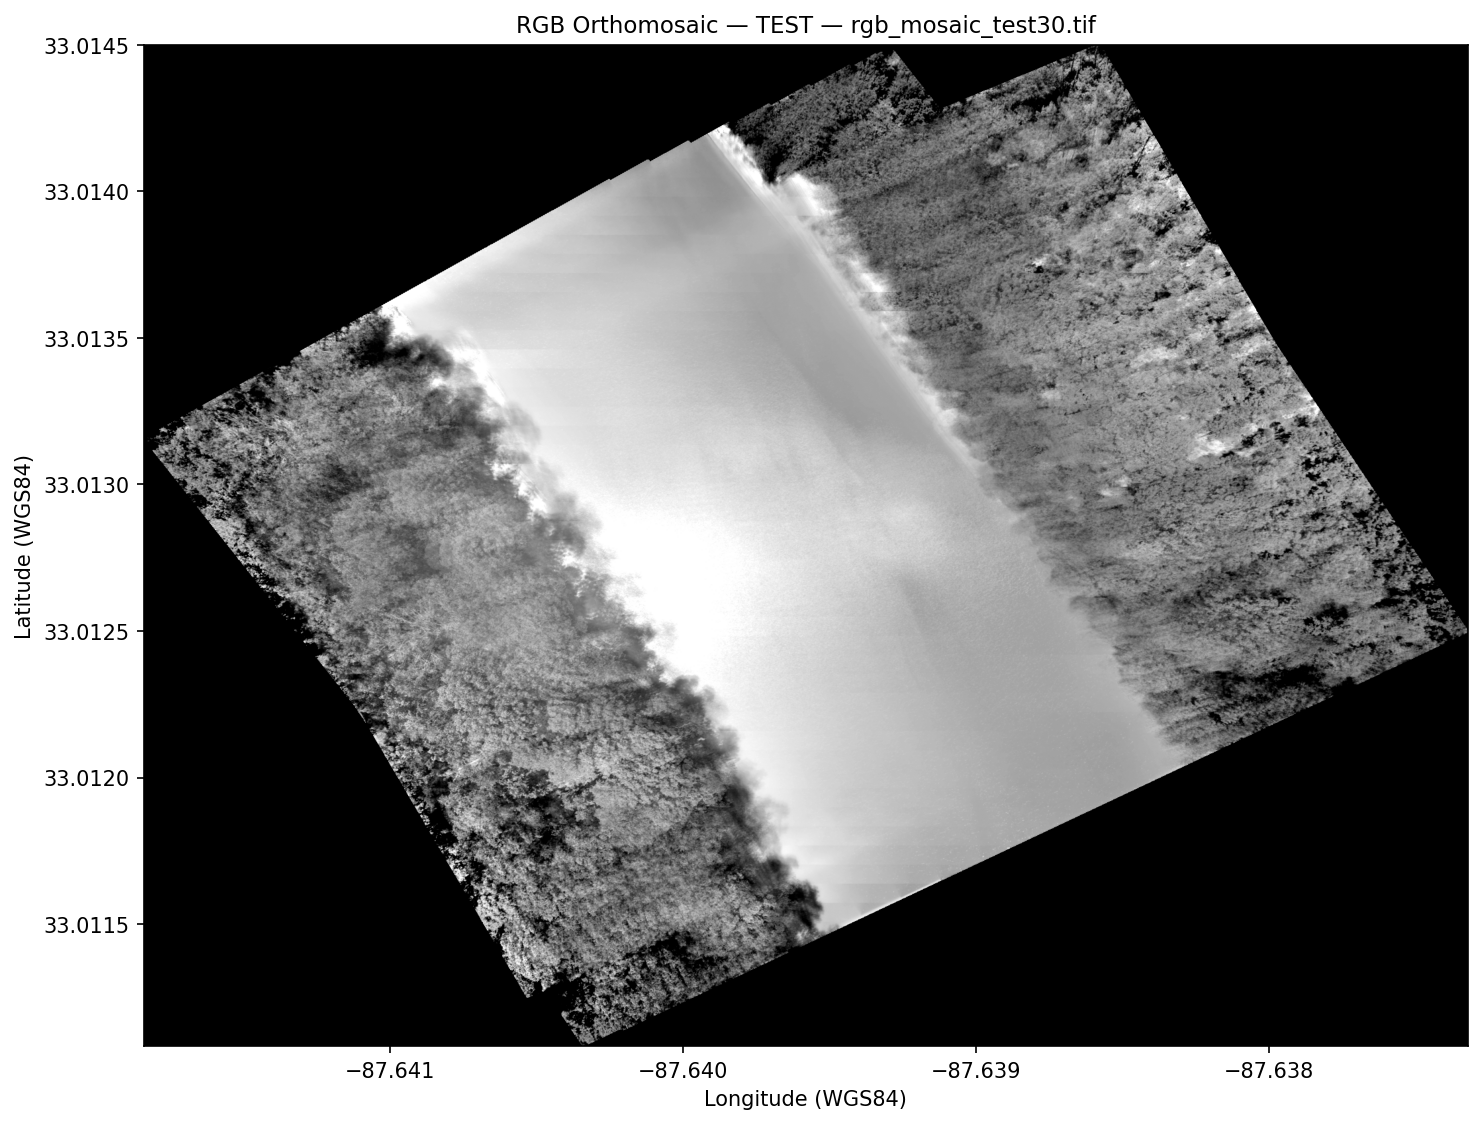

Preview saved: D:\Thermal_Mosaic\RGB\merges\main\rgb_preview.png

TEST done. Set TEST_MODE = False in Cell 0 and re-run Cells 0→3 for full mosaic.


In [5]:
import matplotlib
if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = matplotlib.rcParams.__getitem__
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image as IPImage, display

with rasterio.open(out_path) as src:
    size_mb = os.path.getsize(out_path)/1e6
    print(f'File     : {os.path.basename(out_path)}')
    print(f'Size     : {size_mb:.0f} MB')
    print(f'Shape    : {src.height} x {src.width}  bands={src.count}')
    print(f'Bounds   : {src.bounds}')
    bounds = src.bounds

    # Read for preview (downsample if large)
    scale   = min(1.0, 2000/max(src.width, src.height))
    out_w   = int(src.width*scale)
    out_h   = int(src.height*scale)

    if src.count >= 3:
        data = src.read(
            indexes=[1,2,3],
            out_shape=(3, out_h, out_w),
            resampling=Resampling.bilinear
        ).astype(np.float32)
        rgb_disp = np.moveaxis(data, 0, -1)
        for b in range(3):
            ch = rgb_disp[:,:,b]
            v  = ch[ch > 0]
            if v.size:
                lo, hi = np.percentile(v,2), np.percentile(v,98)
                rgb_disp[:,:,b] = np.clip((ch-lo)/max(hi-lo,1e-6), 0, 1)
        rgb_disp[(rgb_disp[:,:,0]==0)&(rgb_disp[:,:,1]==0)] = 0
        cmap = None
    else:
        data = src.read(
            1, out_shape=(out_h, out_w),
            resampling=Resampling.bilinear
        ).astype(np.float32)
        v = data[data>0]
        if v.size:
            lo,hi = np.percentile(v,2), np.percentile(v,98)
            rgb_disp = np.clip((data-lo)/max(hi-lo,1e-6), 0, 1)
        else:
            rgb_disp = data
        cmap = 'gray'

    valid_px = (src.read(1) > 0).sum()
    total_px = src.height * src.width
    print(f'Coverage : {100*valid_px/total_px:.1f}%')

extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
fig, ax = plt.subplots(figsize=(10,12), dpi=120)
ax.imshow(rgb_disp, extent=extent, aspect='equal',
          origin='upper', cmap=cmap)
ax.set_title(f'RGB Orthomosaic — {"TEST" if TEST_MODE else "FULL"} — '
             f'{os.path.basename(out_path)}', fontsize=11)
ax.set_xlabel('Longitude (WGS84)')
ax.set_ylabel('Latitude (WGS84)')
ax.ticklabel_format(useOffset=False)
plt.tight_layout()
preview_path = os.path.join(MERGE_OUT, 'rgb_preview.png')
fig.savefig(preview_path, bbox_inches='tight', dpi=150)
plt.close(fig)
display(IPImage(filename=preview_path))
print(f'Preview saved: {preview_path}')
if TEST_MODE:
    print()
    print('TEST done. Set TEST_MODE = False in Cell 0 and re-run Cells 0→3 for full mosaic.')